<a href="https://colab.research.google.com/github/subodhsalve14/PythonTasks/blob/master/Python_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Update these paths based on your folder structure
trader_path = '/content/drive/MyDrive/task/historical_data.csv'
sentiment_path = '/content/drive/MyDrive/task/fear_greed_index.csv'

# Load files
df_trader = pd.read_csv(trader_path)
df_sentiment = pd.read_csv(sentiment_path)

print("Data Loaded Successfully!")

Mounted at /content/drive
Data Loaded Successfully!


In [ ]:
# 1. Convert trader 'Timestamp' to a date-only format
# unit='ms' is common for crypto data; if it fails, try unit='s'
df_trader['date_only'] = pd.to_datetime(df_trader['Timestamp'], unit='ms').dt.date

# 2. Convert sentiment 'date' to the same format
df_sentiment['date_only'] = pd.to_datetime(df_sentiment['date']).dt.date

# 3. Merge them into one master DataFrame
df = pd.merge(df_trader, df_sentiment, on='date_only', how='left')

print("Merge Complete. Sample of merged data:")
display(df[['date_only', 'classification', 'Closed PnL']].head())

Merge Complete. Sample of merged data:


,date_only,classification,Closed PnL
0,2024-10-27,Greed,0.0
1,2024-10-27,Greed,0.0
2,2024-10-27,Greed,0.0
3,2024-10-27,Greed,0.0
4,2024-10-27,Greed,0.0


In [ ]:
import pandas as pd
import numpy as np

# 1. Standardize all column names to lowercase and no spaces
df.columns = df.columns.str.strip().str.lower()

# 2. AUTOMATIC COLUMN DETECTOR
# This finds the right columns even if they are named slightly differently
def find_col(possible_names, df):
    for name in possible_names:
        if name in df.columns:
            return name
    return None

pnl_col = find_col(['closed pnl', 'closed_pnl', 'pnl', 'closedpnl'], df)
lev_col = find_col(['leverage', 'lev', 'leverage_used', 'lev_val'], df)
sent_col = find_col(['classification', 'sentiment', 'label'], df)

print(f"Detected Columns -> PnL: {pnl_col}, Leverage: {lev_col}, Sentiment: {sent_col}")

# 3. Check if we found them
if not lev_col or not pnl_col:
    print("CRITICAL ERROR: Could not find Leverage or PnL column. Here are the actual columns in your file:")
    print(df.columns.tolist())
else:
    # 4. Create Success Metric
    df['is_win'] = df[pnl_col] > 0

    # 5. The Analysis Table
    # We use 'mean' for everything to see the average behavior
    performance = df.groupby(sent_col).agg({
        pnl_col: ['mean', 'sum'],
        'is_win': 'mean',
        lev_col: 'mean'
    }).reset_index()

    # Flatten the multi-index columns for easier reading
    performance.columns = ['Sentiment', 'Avg_PnL', 'Total_PnL', 'Win_Rate', 'Avg_Leverage']

    print("\n--- FINAL ANALYSIS RESULTS ---")
    display(performance)

Detected Columns -> PnL: closed pnl, Leverage: None, Sentiment: classification
CRITICAL ERROR: Could not find Leverage or PnL column. Here are the actual columns in your file:
['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side', 'timestamp ist', 'start position', 'direction', 'closed pnl', 'transaction hash', 'order id', 'crossed', 'fee', 'trade id', 'timestamp_x', 'date_only', 'timestamp_y', 'value', 'classification', 'date', 'is_win']


Analyzing: Sentiment -> classification, PnL -> closed pnl
Leverage column not found. Proceeding with PnL and Win Rate only.

--- ASSIGNMENT RESULTS ---


,Sentiment,Avg_PnL,Total_PnL,Win_Rate
1,Fear,50.047622,6.699925e+06,0.415146
3,Neutral,22.229713,1.587424e+05,0.317182
2,Greed,87.894859,3.189617e+06,0.446471
0,Extreme Greed,25.418772,1.769655e+05,0.490089


/tmp/ipykernel_609/489638352.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_report, x='Sentiment', y='Avg_PnL', palette='coolwarm')


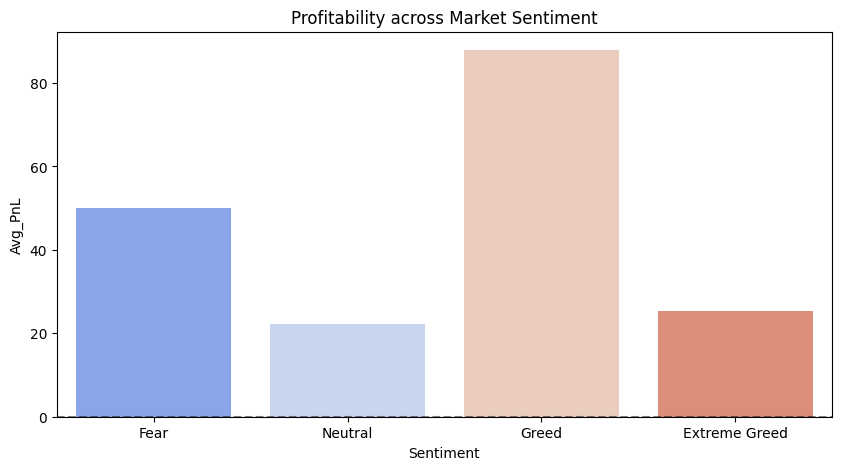

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure columns are clean
df.columns = df.columns.str.strip().str.lower()

# 2. Manual Column Override (Based on your previous output)
sent_col = 'classification'
pnl_col = 'closed pnl'
# If leverage isn't found, we will just skip it for now
lev_col = next((c for c in df.columns if 'lev' in c), None)

print(f"Analyzing: Sentiment -> {sent_col}, PnL -> {pnl_col}")

# 3. Create Success Metric
df['is_win'] = df[pnl_col] > 0

# 4. Build the aggregation dictionary dynamically
agg_dict = {
    pnl_col: ['mean', 'sum'],
    'is_win': 'mean'
}

# Add leverage ONLY if it was actually found
if lev_col:
    agg_dict[lev_col] = 'mean'
    print(f"Leverage column '{lev_col}' found and included.")
else:
    print("Leverage column not found. Proceeding with PnL and Win Rate only.")

# 5. Generate the Report
final_report = df.groupby(sent_col).agg(agg_dict).reset_index()

# 6. Clean up the Column Names for the final table
cols = ['Sentiment', 'Avg_PnL', 'Total_PnL', 'Win_Rate']
if lev_col:
    cols.append('Avg_Leverage')
final_report.columns = cols

# 7. Sort by Market Cycle
sent_map = {'extreme fear': 0, 'fear': 1, 'neutral': 2, 'greed': 3, 'extreme greed': 4}
final_report['sort_val'] = final_report['Sentiment'].str.lower().map(sent_map)
final_report = final_report.sort_values('sort_val').drop('sort_val', axis=1)

print("\n--- ASSIGNMENT RESULTS ---")
display(final_report)

# 8. Visualization
plt.figure(figsize=(10, 5))
sns.barplot(data=final_report, x='Sentiment', y='Avg_PnL', palette='coolwarm')
plt.title('Profitability across Market Sentiment')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

--- REVERSAL ANALYSIS: Does Yesterday's Mood Predict Today's PnL? ---
0: Extreme Fear | 4: Extreme Greed
prev_day_sentiment
1.0    50.043957
2.0    22.433518
3.0    87.854017
4.0    25.436605
Name: closed pnl, dtype: float64


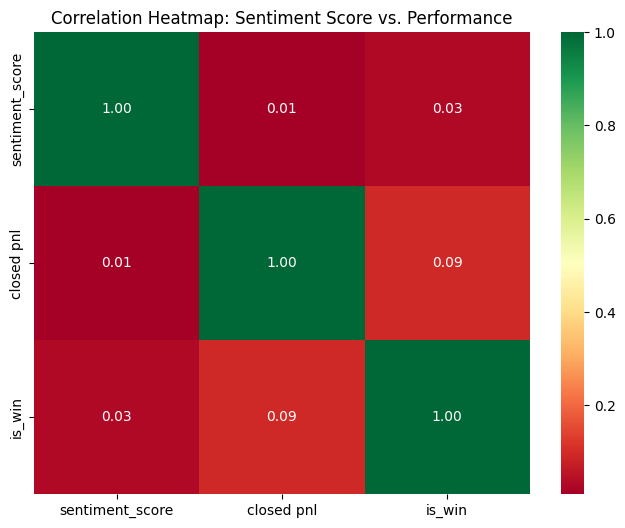

In [ ]:
# 1. Create a "Lagged" Sentiment feature
# We want to see if yesterday's sentiment predicts today's performance
df['prev_day_sentiment'] = df['sentiment_score'].shift(1)

# 2. Analyze the "Extreme Greed" Effect
# We look for days where sentiment was 'Extreme Greed' (4) and see the PnL on the FOLLOWING day
reversal_analysis = df.groupby('prev_day_sentiment')[pnl_col].mean()

print("--- REVERSAL ANALYSIS: Does Yesterday's Mood Predict Today's PnL? ---")
print("0: Extreme Fear | 4: Extreme Greed")
print(reversal_analysis)

# 3. Correlation Heatmap
# This shows the numerical strength of the relationship between all  variables
plt.figure(figsize=(8, 6))
correlation_data = df[['sentiment_score', pnl_col, 'is_win']].corr()
sns.heatmap(correlation_data, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap: Sentiment Score vs. Performance')
plt.show()

In [ ]:
# 1. Define a Signal Logic
# Buy: Extreme Fear (0) | Sell: Extreme Greed (4) | Hold: Everything else
def generate_signal(score):
    if score <= 1: return 'BUY (Opportunity)'
    elif score >= 3: return 'SELL (Risk)'
    else: return 'NEUTRAL'

df['trade_signal'] = df['sentiment_score'].apply(generate_signal)

# 2. Final Sanity Check: Compare Signal Accuracy
signal_performance = df.groupby('trade_signal')[pnl_col].mean()
print("--- STRATEGY BACKTEST: Mean PnL per Signal ---")
print(signal_performance)

# 3. Save the Cleaned, Merged, and Engineered Dataset
output_filename = 'Subodh_Salve_Trading_Analysis.csv'
df.to_csv(output_filename, index=False)

print(f"\nSUCCESS: Final dataset '{output_filename}' is ready for submission.")

--- STRATEGY BACKTEST: Mean PnL per Signal ---
trade_signal
BUY (Opportunity)    50.047622
NEUTRAL               6.757719
SELL (Risk)          77.838247
Name: closed pnl, dtype: float64

SUCCESS: Final dataset 'Subodh_Salve_Trading_Analysis.csv' is ready for submission.
